In [13]:
from datetime import datetime, timezone, timedelta
import fsspec
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import multiprocessing
import numpy as np
import os
import pandas as pd
import re
import xarray as xr

In [26]:
today = datetime.now(timezone.utc).replace(hour = 0, minute=0, second = 0, microsecond=0)
yesterday = today - timedelta(days = 1)
bdt = yesterday.replace(tzinfo=None)
edt = yesterday.replace(hour = 23, minute = 59, second = 59, microsecond=999999,tzinfo=None)

In [27]:
search_condition = '*MET*WIND*.nc'
hourly_dir = '/media/support/data/sikuliaq/hourly'
local = fsspec.filesystem('file')
files = local.glob(os.path.join(hourly_dir,search_condition))

In [29]:
foi = []
for file in files:
    pattern = r'(\d{8}T\d{6}Z)'
    fbdt, fedt = re.findall(pattern, file)
    fbdt = datetime.strptime(fbdt, '%Y%m%dT%H%M%SZ')
    fedt = datetime.strptime(fedt, '%Y%m%dT%H%M%SZ')
    if bdt <= fbdt <= edt:
        foi.append(file)
    elif bdt <= fedt <= edt:
        foi.append(file)
    elif fbdt <= bdt <= fedt:
        foi.append(file)
    elif fbdt <= edt <= fedt:
        foi.append(file)

In [31]:
with multiprocessing.Pool(os.cpu_count()-1) as pool:
    ds_list = pool.map(xr.open_dataset, foi)
ds = xr.combine_by_coords(ds_list, combine_attrs='drop_conflicts')

In [35]:
qartod_vars = [v for v in ds.data_vars if 'qartod_' in v]
for qv in qartod_vars:
    ds[qv] = ds[qv].astype('int8')

In [32]:
tw = ds[['true_wind_speed','true_wind_direction']]
twr = ds.resample({'time': '5min'}, skipna = True).median()

Text(0.5, 1.0, '5-Minute Median Compass')

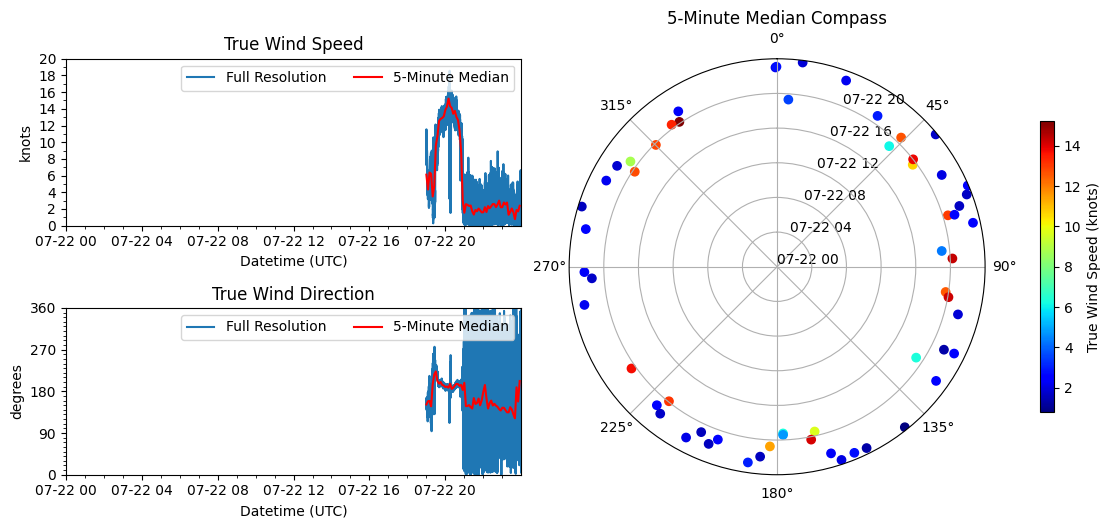

In [34]:
figsize = (11,8.5)
fig = plt.figure(figsize = figsize, constrained_layout = True)
grid = (4,4)
ax1 = plt.subplot2grid(grid, (0,0), colspan = 2,rowspan = 1)
ax2 = plt.subplot2grid(grid, (1,0), colspan = 2,rowspan = 1)
ax3 = plt.subplot2grid(grid, (0,2), colspan = 2,rowspan = 2, projection = 'polar')

ax1.plot(tw.time, tw.true_wind_speed * 1.94384, label = 'Full Resolution')
ax1.plot(twr.time, twr.true_wind_speed * 1.94384, label = '5-Minute Median', color = 'red')

ax1.set_ylabel(r'knots')
ax1.set_ylim(0,20)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.yaxis.set_minor_locator(mticker.MultipleLocator(1))
ax1.set_xlabel('Datetime (UTC)')
ax1.set_xlim(bdt, edt)
ax1.xaxis.set_major_locator(mdates.HourLocator([0,4,8,12,16,20]))
ax1.xaxis.set_minor_locator(mdates.HourLocator(interval = 1))
ax1.legend(loc = 'upper right', ncol = 2)
ax1.set_title('True Wind Speed')


ax2.plot(tw.time, tw.true_wind_direction, label = 'Full Resolution')
ax2.plot(twr.time, twr.true_wind_direction, label = '5-Minute Median', color = 'red')
ax2.set_ylabel(r'degrees')
ax2.set_ylim(0,360)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(90))
ax2.yaxis.set_minor_locator(mticker.MultipleLocator(10))
ax2.set_xlabel('Datetime (UTC)')
ax2.set_xlim(bdt, edt)
ax2.xaxis.set_major_locator(mdates.HourLocator([0,4,8,12,16,20]))
ax2.xaxis.set_minor_locator(mdates.HourLocator(interval = 1))
ax2.legend(loc = 'upper right', ncol = 2)
ax2.set_title('True Wind Direction')


r = twr.time
theta = twr.true_wind_direction
color = twr.true_wind_speed * 1.94384
polar = ax3.scatter(theta, r, c = color, cmap= 'jet', vmin = np.nanmin(twr.true_wind_speed * 1.94384), vmax = np.nanmax(twr.true_wind_speed * 1.94384))
ax3.set_theta_zero_location('N')
ax3.set_theta_direction(-1)
ax3.set_ylim(bdt, edt)
ax3.yaxis.set_major_locator(mdates.HourLocator([0,4,8,12,16,20]))
ax3.yaxis.set_minor_locator(mdates.HourLocator(interval = 1))
fig.colorbar(polar, ax = ax3, label = 'True Wind Speed (knots)', shrink = 0.7)
ax3.set_title('5-Minute Median Compass')